In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2012-01-01'
end = '2023-12-31'

stock = 'MSFT'
data = yf.download(stock,start,end)

/var/folders/_k/41pjm0pd4051klhdyyg2vvzw0000gn/T/ipykernel_63107/2182408526.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace=True)

In [4]:
data


Price,Date,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT
0,2012-01-03,20.965441,21.114242,20.667836,20.793143,64731500
1,2012-01-04,21.458838,21.513659,20.973273,21.004599,80516100
2,2012-01-05,21.678123,21.717281,21.372688,21.443172,56081400
3,2012-01-06,22.014893,22.077546,21.560654,21.560654,99455500
4,2012-01-09,21.725117,22.007058,21.709453,21.967899,59706800
...,...,...,...,...,...,...
3013,2023-12-22,369.077118,369.668309,367.234594,368.190346,17107500
3014,2023-12-26,369.156006,371.402510,368.013043,369.491007,12673100
3015,2023-12-27,368.574585,369.550031,367.333086,368.200163,14905400


In [5]:
mva_100_days=data.Close.rolling(100).mean()

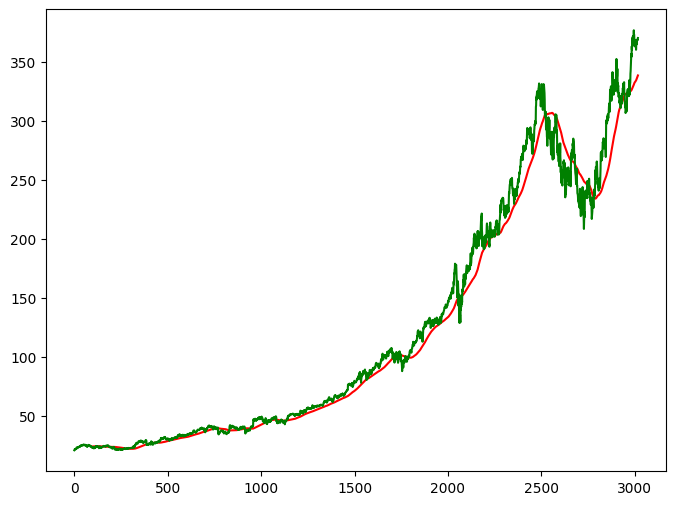

In [6]:
plt.figure(figsize=(8,6))
plt.plot(mva_100_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [7]:
mva_200_days=data.Close.rolling(200).mean()

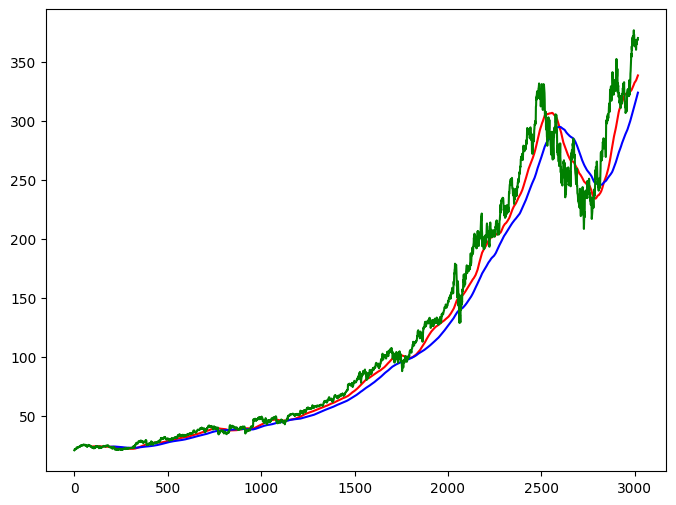

In [8]:
plt.figure(figsize=(8,6))
plt.plot(mva_100_days,'r')
plt.plot(mva_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [9]:
data.dropna(inplace=True)

In [10]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [11]:
data_train.shape[0]

2414

In [12]:
data_test.shape[0]

604

In [13]:
from sklearn.preprocessing import MinMaxScaler as mms
scaler = mms(feature_range=(0,1))


In [14]:
data_train_scale=scaler.fit_transform(data_train)

In [15]:
x=[]
y=[]

for i in range (100,data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [16]:
x, y = np.array(x), np.array(y)

In [17]:

import tensorflow.keras as keras
from keras.layers import Dense, Dropout,LSTM
from keras.models import Sequential


/Users/arpan25/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [18]:
model = Sequential()
model.add(LSTM(units = 50, return_sequences =True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, return_sequences =True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, return_sequences =True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, return_sequences =False))
model.add(Dropout(0.5))

model.add(Dense(units=1))

2025-12-22 11:09:17.716529: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-22 11:09:17.716553: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-22 11:09:17.716558: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-22 11:09:17.716571: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-22 11:09:17.716580: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/arpan25/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequenti

In [19]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')

In [20]:
model.fit(x,y, epochs = 50, batch_size = 32 , verbose = 1)

Epoch 1/50


2025-12-22 11:09:18.965196: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0238
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0031
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0027
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0025
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0024
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0027
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0019
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0019
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0017
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0026
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0018
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0018
Epoch 13/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0019
Epoch 14/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0018
Epoch 15/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0016
Epoch 16/50
73/

In [21]:
pst_100_days=data_train.tail(100)

In [22]:
data_test=pd.concat([pst_100_days,data_test],ignore_index=True)

In [23]:
data_test_scale =  scaler.fit_transform(data_test)

In [24]:
x=[]
y=[]

for i in range (100,data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

x, y = np.array(x), np.array(y)

In [25]:
y_predict = model.predict(x)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [26]:
scale=1/scaler.scale_

In [27]:
y_predict=y_predict*scale

In [28]:
y=y*scale

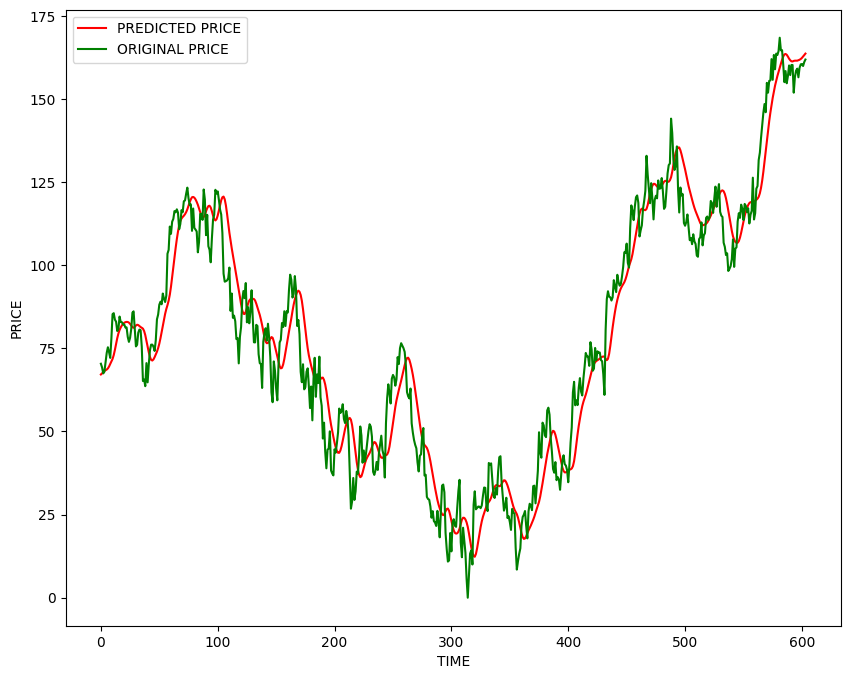

In [29]:
plt.figure(figsize=(10,8))
plt.plot(y_predict,'r',label='PREDICTED PRICE')
plt.plot(y,'g',label='ORIGINAL PRICE')
plt.xlabel('TIME')
plt.ylabel('PRICE')
plt.legend()
plt.show()

In [30]:
model.save('Stock Predictions Model 2025.keras')